In [34]:
import re
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as  plt
EXP = "SENS02"

54200384.40816392 725829.6046372608


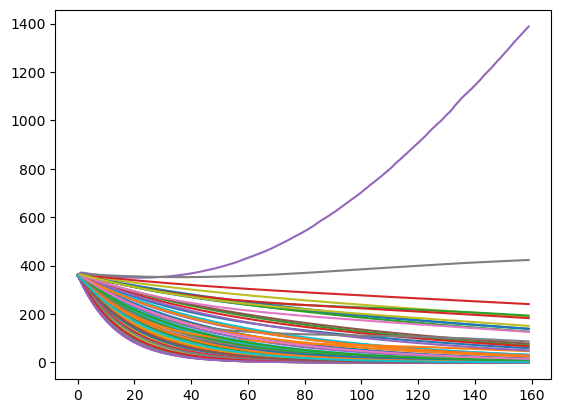

74.67370311417788


In [27]:
ncfile="SENS01_000_P01.802_N02.936_p9.36e-04.nc"
ds = xr.open_dataset(ncfile,decode_timedelta=False)
Biomass = ds.Phytoplankton.sum(dim="particle")
B = Biomass.values
B_tot = np.sum(B, axis=1)
var_tot = np.var(B_tot)
var_sum = np.sum(np.var(B, axis=0))
print(var_tot,var_sum)
plt.plot(B)
plt.show()
print(synchrony(B))

In [45]:
# --- helper: parse filename ---
def parse_filename(fname):
    # Example: SENS_P00.119_N01.128_p3.91e-05_r9.0_6.nc
    # pattern = r"P([0-9.]+)_N([0-9.]+)_p([0-9.eE+-]+)_r([0-9.]+)_(\d+)"
    # SENS01_064_P00.068_N00.817_p2.00e-04.nc
    pattern = r"_(\d+)_P([\d\.]+)_N([\d\.]+)_p([\d\.eE+-]+)\.nc$"
    match = re.search(pattern, fname)

    if match:
        idx = int(match.group(1))
        P0 = float(match.group(2))
        N0 = float(match.group(3))
        p  = float(match.group(4))
        #r  = float(match.group(5))
        return P0, N0, p, idx
    else:
        return None

# --- helper: Simpson index ---
def simpson_index(final_abundances):
    total = np.sum(final_abundances)

    if total == 0:
        return np.nan

    p = final_abundances / total
    D = np.sum(p**2)
    # Hill number 1/D
    return 1 - D   # Simpson diversity


def community_stability(B):
    B_tot = np.sum(B, axis=1)
    mu = np.mean(B_tot)
    sigma = np.std(B_tot)
    return mu / sigma if sigma > 0 else np.nan


def synchrony(B):
    B_tot = np.sum(B, axis=1)

    var_tot = np.var(B_tot)
    var_sum = np.sum(np.var(B, axis=0))

    if var_sum == 0:
        return np.nan

    return var_tot / var_sum


def simpson_time(B):
    # relative abundances
    total = np.sum(B, axis=1, keepdims=True)
    P = np.divide(B, total, where=total > 0)

    D = np.sum(P**2, axis=1)
    return D  # time series


def mean_simpson_diversity(B):
    D = simpson_time(B)
    return np.mean(1 - D)

def dynamic_diversity(B):
    div = mean_simpson_diversity(B)
    stab = community_stability(B)
    phi = synchrony(B)

    asynchrony = 1 - phi if phi is not None else np.nan

    return div * stab * asynchrony

# --- helper: compute multiple ecological metrics ---
def compute_metrics(ncfile):
    EXTINCTION = 1e-4
    ds = xr.open_dataset(ncfile,decode_timedelta=False)

    Biomass = ds.Phytoplankton.sum(dim="particle")
    initial = Biomass.isel(time=0).values
    final   = Biomass.isel(time=-1).values
    survivors = np.sum(final > initial)
    
    richness  = np.sum(final > EXTINCTION)  # extinction threshold
    simpson   = simpson_index(final)
    stability = community_stability(Biomass.values)
    synch     = synchrony(Biomass.values)
    msimpson  = mean_simpson_diversity(Biomass.values)

    ds.close()

    return survivors, richness, simpson, stability, synch, msimpson


In [70]:
# --- main processing ---
files = sorted(glob.glob(f"{EXP}_*.nc"))

records = []

for f in files[:-12]:
    parsed = parse_filename(f)
    if parsed is None:
        continue

    P0, N0, p, idx = parsed

    survivors, richness, simpson, stability, synch, msimpson = compute_metrics(f)

    records.append({
        "P0": P0,
        "N0": N0,
        "p": p,
        "exp_id": idx,
        "survivors": survivors,
        "richness": richness,
        "simpson": simpson,
        "stability": stability,
        "synchrony": synch,
        "mean_simpson": msimpson
    })

# Convert to DataFrame
df = pd.DataFrame(records)

# Optional: set a multi-index for clean analysis
df = df.set_index(["exp_id"])



In [71]:
df

,P0,N0,p,survivors,richness,simpson,stability,synchrony,mean_simpson
exp_id,,,,,,,,,
0,0.899,3.750,1.000000e-03,2,100,0.771059,1.493128,41.088404,0.930279
1,0.942,2.403,1.000000e-06,2,100,0.778520,1.478448,42.697704,0.932532
2,0.342,2.773,1.000000e-04,5,100,0.652712,2.489462,6.772913,0.890592
3,0.872,3.741,1.000000e-04,2,100,0.767217,1.512690,39.169139,0.929339
4,0.374,3.564,1.000000e-05,5,100,0.661016,2.329970,8.266770,0.894839
...,...,...,...,...,...,...,...,...,...
223,0.490,2.150,1.000000e-05,5,100,0.692562,1.986868,14.202333,0.906420
224,0.248,0.603,1.000000e-07,5,100,0.610910,3.413618,2.461968,0.874529
225,0.147,2.819,1.000000e-03,6,100,0.589624,5.719190,0.690281,0.855702


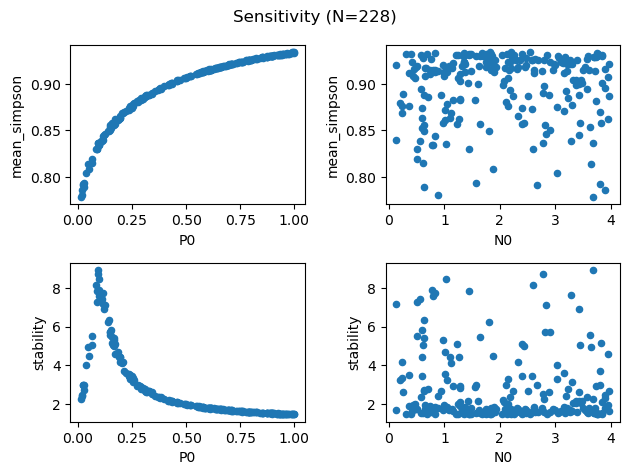

In [72]:
figure,ax = plt.subplots(2,2)
df.plot.scatter(x="P0", y="mean_simpson",ax=ax[0,0])
df.plot.scatter(x="N0", y="mean_simpson",ax=ax[0,1])
df.plot.scatter(x="P0", y="stability",ax=ax[1,0])
df.plot.scatter(x="N0", y="stability",ax=ax[1,1])
plt.suptitle("Sensitivity (N=228)")
plt.tight_layout()
plt.savefig('P0_N0_sensitivity.png')

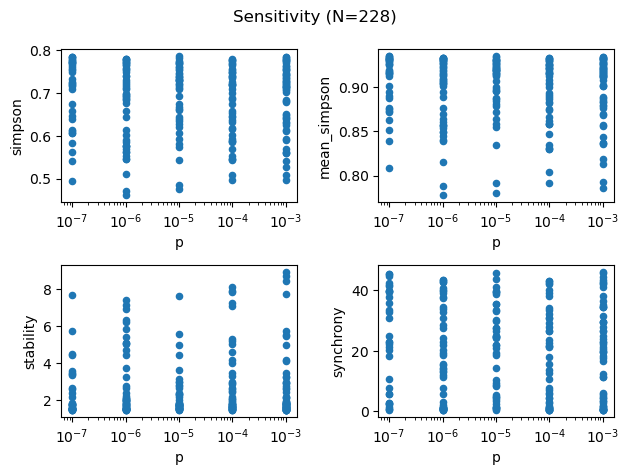

In [73]:
figure,ax = plt.subplots(2,2)
df.plot.scatter(x="p", y="simpson",ax=ax[0,0])
ax[0,0].set_xscale('log')
df.plot.scatter(x="p", y="mean_simpson",ax=ax[0,1])
ax[0,1].set_xscale('log')
df.plot.scatter(x="p", y="stability",ax=ax[1,0])
ax[1,0].set_xscale('log')
df.plot.scatter(x="p", y="synchrony",ax=ax[1,1])
ax[1,1].set_xscale('log')
plt.suptitle("Sensitivity (N=228)")
plt.tight_layout()
plt.savefig('p_sensitivity.png')

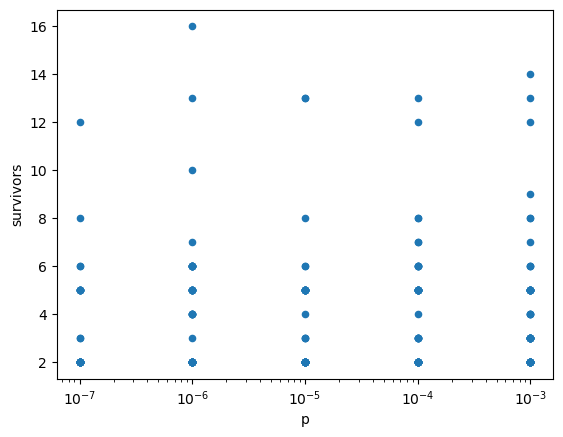

In [74]:
df.plot.scatter(x="p", y="survivors")
plt.xscale('log')